In [1]:
#download mnist data
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', data_home='../mnist_data/', as_frame=False, parser='liac-arff')

X = mnist.data
y = mnist.target
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(60000, 784) (60000,)
(10000, 784) (10000,)


In [2]:
#imports
import numpy as np
from brian2 import *
import os


from eqn_clopath import *
from network_clopath import *
from utils import *

prefs.codegen.target = 'cython'
# prefs.codegen.target = 'numpy'
defaultclock.dt = 0.1 * ms

In [3]:
num_examples = 100
time_per_block = 50 * ms
blocks_per_image = 7
blocks_per_rest = 3
total_blocks = blocks_per_image + blocks_per_rest

rates_array = np.zeros((num_examples * total_blocks, n_input), dtype=np.float32)
for idx in range(num_examples):
    img_rates = X_train[idx] / 4.0 + 10 # black pixels spike at 10 Hz
    start_idx = idx * total_blocks
    rates_array[start_idx : start_idx + blocks_per_image, :] = img_rates

input_rates = TimedArray(rates_array * Hz, dt=time_per_block, name='input_rates')
batch_start_time = 0 * ms

start_scope()
net, inp_group, spike_monitor = build_network_train()

net.run(
    num_examples * total_blocks * time_per_block,
    report='text', report_period=60*second
)


Starting simulation at t=0. s for a duration of 50. s
12.9372 s (25%) simulated in 1m 0s, estimated 2m 52s remaining.
25.8108 s (51%) simulated in 2m 0s, estimated 1m 52s remaining.
38.795 s (77%) simulated in 3m 0s, estimated 52s remaining.
50. s (100%) simulated in 3m 51s


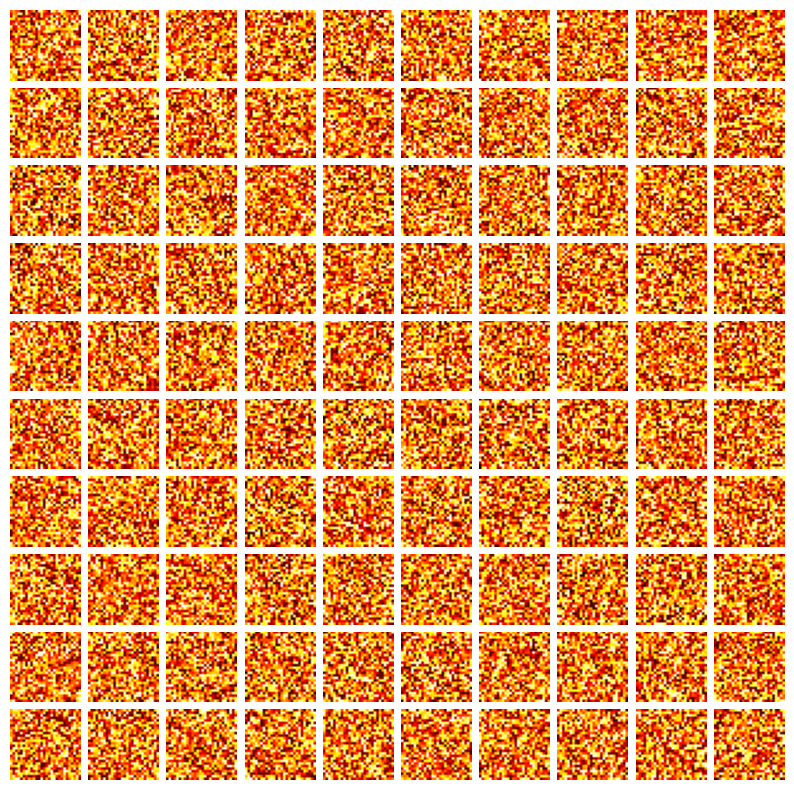

In [4]:
# plotting the receptive field    
final_weights = get_2d_weights(net['s_inp_exc'], n_input, n_e)
plot_weights(final_weights, n_e)

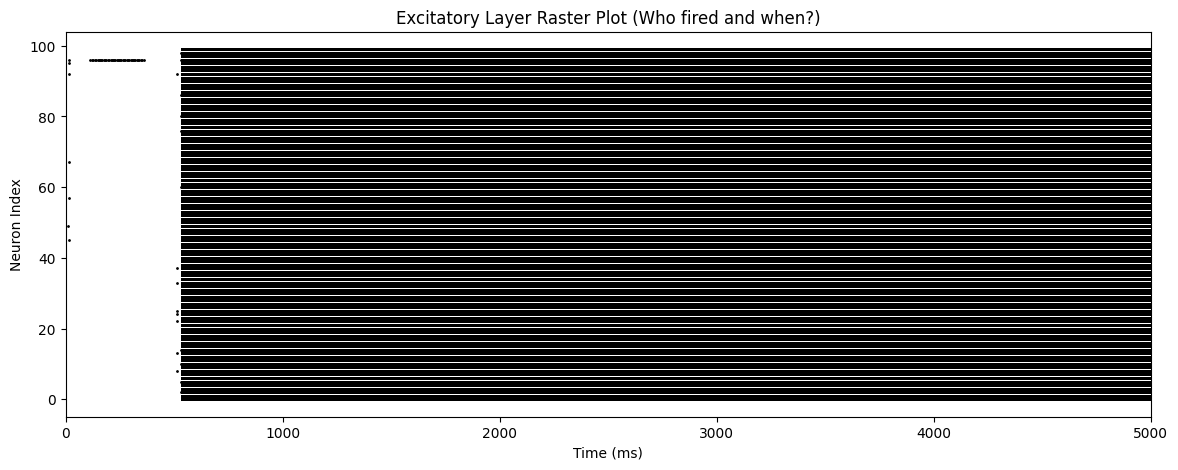

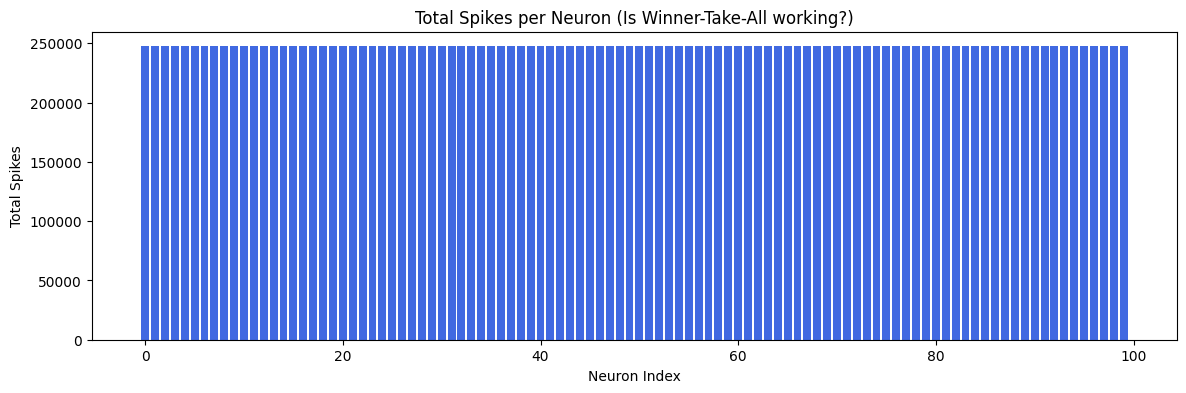

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Raster Plot: Shows EXACTLY when each neuron fired
plt.figure(figsize=(14, 5))
plt.plot(spike_monitor.t / ms, spike_monitor.i, '.k', markersize=2)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.title('Excitatory Layer Raster Plot (Who fired and when?)')
# Limit the view to the first few images (e.g., first 2000 ms) so it isn't too squished
plt.xlim(0, 5000) 
plt.show()

# 2. Total Spikes per Neuron: Shows who the "winners" were
plt.figure(figsize=(14, 4))
spike_counts = np.array(spike_monitor.count)
plt.bar(range(len(spike_counts)), spike_counts, color='royalblue')
plt.xlabel('Neuron Index')
plt.ylabel('Total Spikes')
plt.title('Total Spikes per Neuron (Is Winner-Take-All working?)')
plt.show()

In [ ]:
# saving the trained model weights

save_path = '../trained_model/clopath'
if not os.path.exists(save_path):
    os.makedirs(save_path)

trained_weights = np.array(net['s_inp_exc'].w)
np.save(os.path.join(save_path, 'weights.npy'), trained_weights)

trained_theta = np.array(net['exc'].theta)
np.save(os.path.join(save_path, 'thetas.npy'), trained_theta)